<a href="https://colab.research.google.com/github/prquerque/Rodrigo-Albuquerque/blob/main/Aula08_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [9]:

# Instala o virtualenv e cria o ambiente
!pip install virtualenv
!virtualenv meu_ambiente

# Para usar o ambiente, execute o comando de instalação ativando-o na mesma linha
!source /content/meu_ambiente/bin/activate; pip install nome_do_pacote

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 19.4 MB/s eta 0:00:00
created virtual environment CPython3.12.11.final.0-64 in 399ms
  creator CPython3Posix(dest=/content/meu_ambiente, clear=False, no_vcs_ignore=False, global=False)
  seeder FromAppData(download=False, pip=bundle, via=copy, app_data_dir=/root/.local/share/virtualenv)
    added seed packages: pip==25.2
  activators BashActivator,CShellActivator,FishActivator,NushellActivator,PowerShellActivator,PythonActivator


In [13]:

from google.colab import files
uploaded = files.upload()

In [12]:
!pip install openai

In [17]:
pip install pydantic

In [14]:

from datetime import datetime

from pydantic import BaseModel, PositiveInt


class User(BaseModel):
    id: int
    name: str = 'John Doe'
    signup_ts: datetime | None
    tastes: dict[str, PositiveInt]


external_data = {
    'id': 123,
    'signup_ts': '2019-06-01 12:22',
    'tastes': {
        'wine': 9,
        b'cheese': 7,
        'cabbage': '1',
    },
}

user = User(**external_data)

print(user.id)
#> 123
print(user.model_dump())
"""
{
    'id': 123,
    'name': 'John Doe',
    'signup_ts': datetime.datetime(2019, 6, 1, 12, 22),
    'tastes': {'wine': 9, 'cheese': 7, 'cabbage': 1},
}
"""

123
{'id': 123, 'name': 'John Doe', 'signup_ts': datetime.datetime(2019, 6, 1, 12, 22), 'tastes': {'wine': 9, 'cheese': 7, 'cabbage': 1}}


"\n{\n    'id': 123,\n    'name': 'John Doe',\n    'signup_ts': datetime.datetime(2019, 6, 1, 12, 22),\n    'tastes': {'wine': 9, 'cheese': 7, 'cabbage': 1},\n}\n"

In [16]:
from pydantic import BaseModel

class Pessoa(BaseModel):
   nome: str
   idade: int
   altura: float
   peso: float

# Assuming 'app' and '@app.get' are defined elsewhere in your notebook,
# for example, if you are using FastAPI.
# If not, you'll need to define your application instance.

# @app.get("/pessoa/{nome}/{idade}/{altura}/{peso}")
# def get_pessoa(nome: str, idade:int, altura:float, peso:float):
#   return Pessoa(nome=nome, idade=idade, altura=altura, peso=peso)

In [18]:

# Instalar a biblioteca openai (compatível com DeepSeek)
!pip install openai

# Configurar a chave da API
import openai
import os

# Substitua pela sua chave de API da DeepSeek
os.environ["DEEPSEEK_API_KEY"] = "sua_chave_aqui"

# Configurar o cliente OpenAI para DeepSeek
client = openai.OpenAI(
    api_key=os.environ["DEEPSEEK_API_KEY"],
    base_url="https://api.deepseek.com/v1"  # URL da API DeepSeek
)


    🏥 CALCULADORA DE IMC AVANÇADA
    

📝 Digite seus dados:
❌ Erro: Digite valores numéricos válidos!

📝 Digite seus dados:

📊 RESULTADO:
• Peso: 83.0 kg
• Altura: 176.0 m
• IMC: 0.0
• Classificação: Abaixo do peso


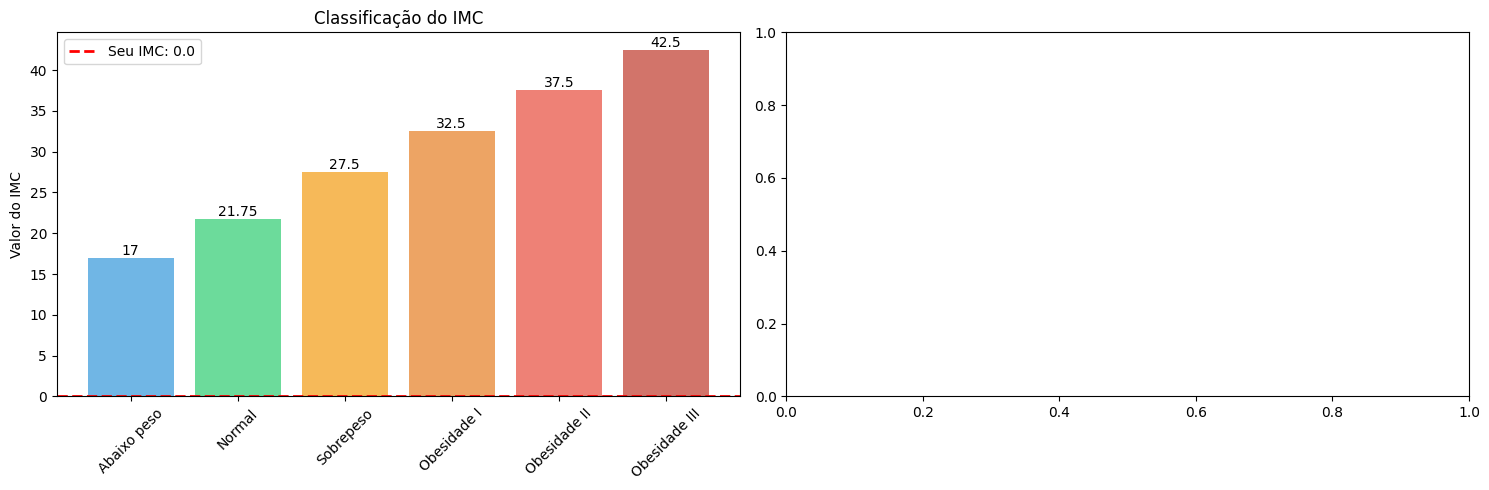


💡 RECOMENDAÇÕES PERSONALIZADAS:

            🔹 Estratégias para ganho de peso saudável:
            • Aumente o consumo de alimentos nutritivos e calóricos
            • Faça refeições menores e mais frequentes
            • Inclua proteínas em todas as refeições
            • Pratique musculação para ganho de massa muscular
            • Consulte um nutricionista para plano alimentar personalizado
            
📋 Faixa de peso ideal para sua altura: 573056.0kg a 771302.4kg

🔁 Deseja fazer novo cálculo? (s/n): N

📈 Resumo da sessão: 1 cálculo(s) realizado(s)


In [23]:

# 📊 CALCULADORA DE IMC - GOOGLE COLAB
# @author: Seu Nome
# @version: 1.0

# Instalar bibliotecas necessárias (executar apenas uma vez)
!pip install matplotlib seaborn

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Configuração do estilo visual
plt.style.use('default')
sns.set_palette("husl")

class CalculadoraIMC:
    def __init__(self):
        self.historico = []
        self.classificacoes = {
            (0, 18.5): "Abaixo do peso",
            (18.5, 25): "Peso normal",
            (25, 30): "Sobrepeso",
            (30, 35): "Obesidade Grau I",
            (35, 40): "Obesidade Grau II",
            (40, float('inf')): "Obesidade Grau III"
        }

    def calcular_imc(self, peso, altura):
        """Calcula o IMC e retorna resultado detalhado"""
        try:
            imc = peso / (altura ** 2)
            classificacao = self.classificar_imc(imc)

            resultado = {
                'peso': peso,
                'altura': altura,
                'imc': round(imc, 2),
                'classificacao': classificacao,
                'peso_ideal_min': round(18.5 * (altura ** 2), 2),
                'peso_ideal_max': round(24.9 * (altura ** 2), 2)
            }

            self.historico.append(resultado)
            return resultado

        except ZeroDivisionError:
            return {"erro": "Altura não pode ser zero!"}

    def classificar_imc(self, imc):
        """Classifica o IMC de acordo com a tabela padrão"""
        for faixa, classificacao in self.classificacoes.items():
            if faixa[0] <= imc < faixa[1]:
                return classificacao
        return "Classificação não encontrada"

    def plotar_grafico_imc(self, imc_atual):
        """Gera um gráfico visual mostrando a posição do IMC"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        # Gráfico 1: Faixas de IMC
        faixas = ['Abaixo peso', 'Normal', 'Sobrepeso', 'Obesidade I', 'Obesidade II', 'Obesidade III']
        valores = [17, 21.75, 27.5, 32.5, 37.5, 42.5]
        cores = ['#3498db', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']

        bars = ax1.bar(faixas, valores, color=cores, alpha=0.7)
        ax1.axhline(y=imc_atual, color='red', linestyle='--', linewidth=2, label=f'Seu IMC: {imc_atual}')
        ax1.set_title('Classificação do IMC')
        ax1.set_ylabel('Valor do IMC')
        ax1.legend()
        ax1.tick_params(axis='x', rotation=45)

        # Adicionar valores nas barras
        for bar, valor in zip(bars, valores):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{valor}', ha='center', va='bottom')

        # Gráfico 2: Evolução do histórico
        if len(self.historico) > 1:
            imcs = [registro['imc'] for registro in self.historico]
            ax2.plot(range(len(imcs)), imcs, marker='o', linewidth=2, markersize=8)
            ax2.set_title('Evolução do IMC')
            ax2.set_xlabel('Medições')
            ax2.set_ylabel('IMC')
            ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def gerar_recomendacoes(self, resultado):
        """Gera recomendações personalizadas baseadas no IMC"""
        imc = resultado['imc']
        classificacao = resultado['classificacao']

        print("\n💡 RECOMENDAÇÕES PERSONALIZADAS:")
        print("=" * 50)

        if imc < 18.5:
            print("""
            🔹 Estratégias para ganho de peso saudável:
            • Aumente o consumo de alimentos nutritivos e calóricos
            • Faça refeições menores e mais frequentes
            • Inclua proteínas em todas as refeições
            • Pratique musculação para ganho de massa muscular
            • Consulte um nutricionista para plano alimentar personalizado
            """)

        elif 18.5 <= imc < 25:
            print("""
            ✅ Parabéns! Você está na faixa de peso ideal:
            • Mantenha hábitos alimentares saudáveis
            • Continue com a prática regular de exercícios
            • Faça check-ups anuais
            • Mantenha a hidratação adequada
            """)

        elif 25 <= imc < 30:
            print("""
            ⚠️ Estratégias para perda de peso moderada:
            • Reduza o consumo de alimentos ultraprocessados
            • Aumente a ingestão de frutas e vegetais
            • Pratique atividades físicas regulares (150 min/semana)
            • Controle o tamanho das porções
            • Beba bastante água
            """)

        else:
            print("""
            🚨 Recomendações importantes:
            • Procure acompanhamento médico especializado
            • Consulte um nutricionista para plano alimentar
            • Inicie atividades físicas com orientação profissional
            • Estabeleça metas realistas de perda de peso
            • Considere acompanhamento psicológico se necessário
            """)

        print(f"📋 Faixa de peso ideal para sua altura: {resultado['peso_ideal_min']}kg a {resultado['peso_ideal_max']}kg")

# 🎯 PROGRAMA PRINCIPAL
def main():
    print("""
    🏥 CALCULADORA DE IMC AVANÇADA
    ==============================
    """)

    calculadora = CalculadoraIMC()

    while True:
        try:
            print("\n📝 Digite seus dados:")
            peso = float(input("• Peso (kg): "))
            altura = float(input("• Altura (m): "))

            if peso <= 0 or altura <= 0:
                print("❌ Erro: Peso e altura devem ser valores positivos!")
                continue

            resultado = calculadora.calcular_imc(peso, altura)

            if 'erro' in resultado:
                print(f"❌ {resultado['erro']}")
                continue

            # Exibir resultados
            print(f"\n📊 RESULTADO:")
            print(f"• Peso: {resultado['peso']} kg")
            print(f"• Altura: {resultado['altura']} m")
            print(f"• IMC: {resultado['imc']}")
            print(f"• Classificação: {resultado['classificacao']}")

            # Gerar gráfico
            calculadora.plotar_grafico_imc(resultado['imc'])

            # Gerar recomendações
            calculadora.gerar_recomendacoes(resultado)

            # Opção para novo cálculo
            continuar = input("\n🔁 Deseja fazer novo cálculo? (s/n): ").lower()
            if continuar != 's':
                break

        except ValueError:
            print("❌ Erro: Digite valores numéricos válidos!")
        except KeyboardInterrupt:
            print("\n👋 Programa encerrado pelo usuário!")
            break

    # Relatório final
    if calculadora.historico:
        print(f"\n📈 Resumo da sessão: {len(calculadora.historico)} cálculo(s) realizado(s)")

# Executar o programa
if __name__ == "__main__":
    main()